# Food-101: CNN y CNN con multihead attention

**Objetivo:** entrenar dos clasificadores de 101 comidas, buscar una buena
configuración con validación y comparar su efectividad y coste en el mismo test.
Este cuaderno contiene dos partes experimentales y una evaluación conjunta.
«Mejores métricas» significa el mejor resultado entre las configuraciones
probadas; no se garantiza un máximo global ni superar a la CNN con atención.

**Ejecución:** seleccione un kernel con PyTorch y ejecute las celdas en orden.
El perfil predeterminado `completo` usa todas las imágenes oficiales y puede
necesitar varias horas de GPU. `rapido` sirve para explorar; `smoke` verifica el
código y sus cifras **no son resultados del experimento completo**.
Los resultados se calculan al ejecutar; no se incluyen métricas inventadas.

## 1. Análisis de los cuadernos de referencia

| Referencia | Idea que conservamos | Adaptación a Food-101 |
|---|---|---|
| `cnns.ipynb` | Conv2d, activaciones, pooling, logits y CrossEntropyLoss | RGB, 101 salidas, carga por lotes y métricas ponderadas por muestra |
| `arquitecturas.ipynb` | Arquitecturas profundas y transferencia de aprendizaje | EfficientNetV2-S con pesos ImageNet y ajuste de todo el extractor |
| `multihead_attention.ipynb` | Imágenes como secuencias; proyecciones Q, K, V; varias cabezas | Tokens visuales, posición 2D, conexiones residuales, LayerNorm y MLP |

El ejemplo de atención divide MNIST en 16 parches de 7×7 y amplía cada
proyección de F a F·h. Su `view(B,L,F,h).transpose(1,3)` produce ejes
`(B,h,F,L)`, aunque el comentario declara `(B,h,L,F)`; por eso la operación
siguiente relaciona características en lugar de los tokens declarados.
Aquí se usa `nn.MultiheadAttention(batch_first=True)`, con secuencias
`(B,N,D)` y dimensión por cabeza `D/h`. Una prueba comprueba que los mapas
resultantes tienen forma `(B,h,N,N)` y suman uno por fila en evaluación.
También evitamos `np.int` y la configuración antigua `Trainer(gpus=1)`.

El cuaderno adicional `food101_cnn_clasificacion.ipynb` trabaja desde cero,
filtra tamaños y utiliza test como validación. Sus cifras guardadas no forman
parte de esta comparación: aquí reservamos una validación independiente y
mantenemos el test oficial completo. No se descartan fotos por su resolución.

## 2. Protocolo experimental

Food-101 tiene 101 clases: 750 imágenes de entrenamiento y 250 de test por
clase. Separamos las 750 en **600 train + 150 validación** con semilla fija:
**60 600 / 15 150 / 25 250 imágenes**. El entrenamiento oficial contiene ruido
de etiquetas. Fuente: [Food-101, ETH Zürich](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/).

Ambos modelos comparten datos, pesos iniciales del extractor, aumentos,
resolución, número máximo de épocas, candidatos y criterio de selección.
Cada uno se entrena independientemente desde ImageNet. La segunda parte es un
**modelo híbrido CNN + MHA**: evalúa el aporte de la atención sobre la misma
representación convolucional; no es un ViT puro. Su cabeza tiene más parámetros,
así que una mejora no puede atribuirse exclusivamente al mecanismo de atención.

Los hiperparámetros y checkpoints se eligen por **accuracy de validación**
(desempate: menor entropía cruzada). Test se consulta después de elegir ambos
modelos. No se prueba aumentación en test ni se ajusta el modelo tras ver test.

## 3. Entorno y configuración

Dependencias: `torch`, `torchvision`, `numpy`, `pandas`, `scikit-learn`,
`matplotlib`, `Pillow`, `tqdm`, `ipykernel`.
En este equipo se verificó el entorno conda `ds_env` con PyTorch 2.12.0+cu130
y torchvision 0.27.0+cu130. Selecciónelo como kernel. Para otro equipo consulte
el [instalador oficial de PyTorch](https://pytorch.org/get-started/locally/)
para escoger la variante CUDA compatible; no reinstale una variante CPU sobre
un entorno GPU que ya funciona. Las dependencias auxiliares se pueden instalar
en el kernel con `%pip install numpy pandas scikit-learn matplotlib pillow tqdm`.
El dataset **no se descarga**. Solo los pesos ImageNet (~83 MB) se descargan
una vez si no están en la caché indicada.


In [1]:
import os
import sys
import gc
import json
import math
import time
import random
import hashlib
import platform
from pathlib import Path
from contextlib import nullcontext
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, log_loss,
)

@dataclass
class Config:
    perfil: str = "completo"  # completo | rapido | smoke
    raiz: str = "datos_food101/food-101"
    salida: str = "resultados_food101"
    semilla: int = 42
    imagen: int = 320
    batch: int = 8             # micro-lote conservador para GPU de 8 GB
    acumulacion: int = 4       # lote efectivo = 32 (último grupo puede ser menor)
    workers: int = 0           # seguro en notebooks Windows; Linux: probar 2 o 4
    epocas_cabeza: int = 2
    epocas_finetune: int = 12
    paciencia: int = 4
    label_smoothing: float = 0.1
    dimension: int = 256
    cabezas: int = 8
    bloques_atencion: int = 2
    dropout: float = 0.2
    preentrenado: bool = True
    reutilizar_completados: bool = True
    dispositivo: str = "auto"

CFG = Config()

# Estas variables permiten ejecutar una validación separada sin editar el cuaderno.
CFG.perfil = os.environ.get("FOOD101_PERFIL", CFG.perfil)
CFG.raiz = os.environ.get("FOOD101_RAIZ", CFG.raiz)
CFG.salida = os.environ.get("FOOD101_SALIDA", CFG.salida)
CFG.dispositivo = os.environ.get("FOOD101_DEVICE", CFG.dispositivo)
if CFG.perfil == "rapido":
    CFG.imagen, CFG.epocas_cabeza, CFG.epocas_finetune = 224, 1, 3
elif CFG.perfil == "smoke":
    CFG.imagen, CFG.batch, CFG.acumulacion = 64, 8, 2
    CFG.epocas_cabeza, CFG.epocas_finetune, CFG.paciencia = 1, 1, 2
elif CFG.perfil != "completo":
    raise ValueError("Perfil desconocido; use completo, rapido o smoke.")

CANDIDATOS = [
    {"nombre": "lr_baja", "lr_backbone": 3e-5, "lr_cabeza": 3e-4, "wd": 1e-4},
    {"nombre": "lr_alta", "lr_backbone": 1e-4, "lr_cabeza": 1e-3, "wd": 1e-4},
]
if CFG.perfil != "completo":
    CANDIDATOS = CANDIDATOS[:1]
assert CFG.dimension % CFG.cabezas == 0 and CFG.dimension % 4 == 0
assert CFG.imagen >= 33 and CFG.batch > 0 and CFG.acumulacion > 0
assert CFG.epocas_cabeza >= 1 and CFG.epocas_finetune >= 1

def sembrar(semilla):
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)

sembrar(CFG.semilla)
DEVICE = torch.device(
    ("cuda" if torch.cuda.is_available() else "cpu")
    if CFG.dispositivo == "auto" else CFG.dispositivo
)
AMP = DEVICE.type == "cuda"
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# Semillas y cuDNN estable ayudan; no garantizan igualdad bit a bit entre equipos.
torch.set_num_threads(min(8, os.cpu_count() or 1))
OUT = Path(CFG.salida).resolve() / CFG.perfil
OUT.mkdir(parents=True, exist_ok=True)
torch.hub.set_dir(str(Path(CFG.salida).resolve() / "cache_torch"))
ENTORNO = {
    "python": sys.version, "torch": str(torch.__version__),
    "torchvision": str(torchvision.__version__), "sistema": platform.platform(),
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(DEVICE) if AMP else None,
}
print(json.dumps(ENTORNO, indent=2, ensure_ascii=False))
display(pd.Series(asdict(CFG), name="Configuración"))
if CFG.perfil != "completo":
    print("AVISO: subconjunto de desarrollo; no es el benchmark completo de Food-101.")
if not AMP:
    print("CPU: el entrenamiento completo será lento. Use GPU para el experimento final.")


{
  "python": "3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]",
  "torch": "2.12.0+cu130",
  "torchvision": "0.27.0+cu130",
  "sistema": "Windows-10-10.0.26200-SP0",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 5050 Laptop GPU"
}


perfil                                  completo
raiz                      datos_food101/food-101
salida                        resultados_food101
semilla                                       42
imagen                                       320
batch                                          8
acumulacion                                    4
workers                                        0
epocas_cabeza                                  2
epocas_finetune                               12
paciencia                                      4
label_smoothing                              0.1
dimension                                    256
cabezas                                        8
bloques_atencion                               2
dropout                                      0.2
preentrenado                                True
reutilizar_completados                      True
dispositivo                                 auto
Name: Configuración, dtype: object

## 4. Dataset local y particiones sin fuga de información

Se espera `datos_food101/food-101/{images,meta}`. También puede cambiar
`CFG.raiz` por una ruta absoluta. Si falta la extracción, extraiga el archivo
local `datos_food101/food-101.tar.gz` y vuelva a ejecutar; no hace falta
descargarlo. Una imagen faltante o dañada genera un error explícito.
El manifiesto conserva las rutas relativas, etiquetas y partición usada.
El submuestreo de los perfiles de desarrollo ocurre **después** de reservar
la validación, mantiene las 101 clases y nunca mezcla las particiones.


In [2]:
RAIZ = Path(CFG.raiz).expanduser().resolve()

def cargar_particiones(raiz, perfil, semilla):
    oficiales = {}
    for split in ("train", "test"):
        archivo = raiz / "meta" / f"{split}.json"
        try:
            oficiales[split] = json.loads(archivo.read_text(encoding="utf-8"))
        except (FileNotFoundError, PermissionError) as exc:
            raise RuntimeError(f"No se puede leer {archivo}. Revise la ruta, extracción y permisos.") from exc
    clases = sorted(oficiales["train"])
    assert len(clases) == 101 and clases == sorted(oficiales["test"])
    limites = {"completo": (600, 150, 250), "rapido": (100, 30, 50), "smoke": (2, 1, 1)}[perfil]
    rng = np.random.default_rng(semilla)
    filas, todos_train, todos_test = [], set(), set()
    for etiqueta, clase in enumerate(clases):
        tr, te = sorted(oficiales["train"][clase]), sorted(oficiales["test"][clase])
        assert len(tr) == len(set(tr)) == 750
        assert len(te) == len(set(te)) == 250
        assert all(r.startswith(clase + "/") for r in tr + te)
        todos_train.update(tr)
        todos_test.update(te)
        tr = [tr[i] for i in rng.permutation(len(tr))]
        te = [te[i] for i in rng.permutation(len(te))]
        grupos = {"train": tr[150:][:limites[0]], "val": tr[:150][:limites[1]], "test": te[:limites[2]]}
        for split, rutas in grupos.items():
            filas.extend({"ruta": r + ".jpg", "clase": clase, "label": etiqueta, "split": split} for r in rutas)
    assert len(todos_train) == 75750 and len(todos_test) == 25250
    assert todos_train.isdisjoint(todos_test)
    df = pd.DataFrame(filas).sort_values(["split", "label", "ruta"]).reset_index(drop=True)
    assert not df.ruta.duplicated().any(), "Hay imágenes repetidas entre particiones."
    faltan = [r for r in df.ruta if not (raiz / "images" / r).is_file()]
    if faltan:
        raise FileNotFoundError(f"Faltan {len(faltan)} imágenes. Primeras: {faltan[:3]}")
    return clases, df

CLASES, MANIFIESTO = cargar_particiones(RAIZ, CFG.perfil, CFG.semilla)
N_CLASES = len(CLASES)
SPLIT_HASH = hashlib.sha256(MANIFIESTO.to_csv(index=False).encode()).hexdigest()
MANIFIESTO.to_csv(OUT / "particiones.csv", index=False)
(OUT / "clases.json").write_text(json.dumps(CLASES, indent=2), encoding="utf-8")
FRAMES = {s: MANIFIESTO[MANIFIESTO.split == s].reset_index(drop=True) for s in ("train", "val", "test")}
display(MANIFIESTO.groupby("split").agg(imagenes=("ruta", "size"), clases=("label", "nunique")))
print("Identificador de partición:", SPLIT_HASH[:16])


,imagenes,clases
split,,
test,25250,101
train,60600,101
val,15150,101


Identificador de partición: 02a9b0df976e5aee


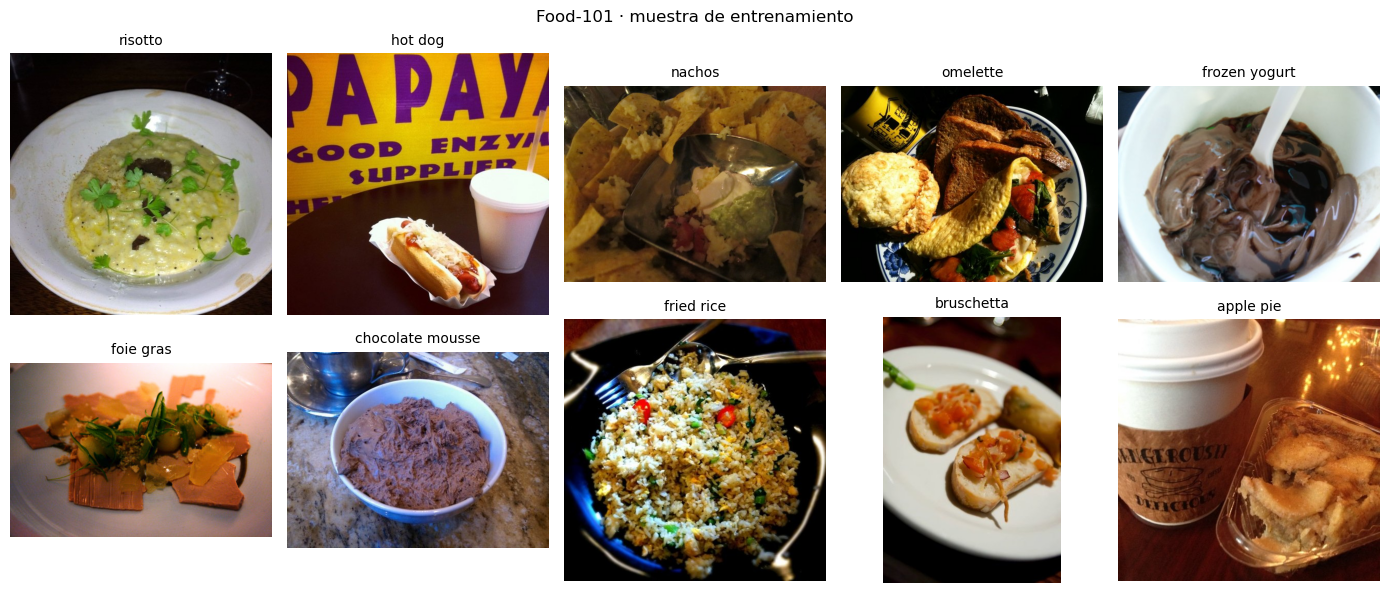

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
muestra = FRAMES["train"].groupby("clase", sort=True).head(1).sample(10, random_state=CFG.semilla)
for ax, fila in zip(axes.flat, muestra.itertuples()):
    with Image.open(RAIZ / "images" / fila.ruta) as im:
        ax.imshow(im.convert("RGB"))
    ax.set_title(fila.clase.replace("_", " "), fontsize=10)
    ax.axis("off")
fig.suptitle("Food-101 · muestra de entrenamiento")
fig.tight_layout()
plt.show()


## 5. Preprocesamiento común

Train usa recortes aleatorios, reflexión horizontal y RandAugment moderado.
Validación/test usan resize conservando la relación de aspecto y recorte
central. Ambas redes reciben exactamente la misma receta de entrada.
Se usa normalización ImageNet. El perfil completo trabaja a 320 px para
contener memoria; los pesos oficiales se publican con evaluación a 384 px.
Cambiar a 384 debe decidirse con validación **antes** de evaluar test.
Véase la [documentación de EfficientNetV2-S](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_v2_s.html).

La semilla de cada aumento depende de imagen y época, de modo que también se
mantienen iguales entre CNN y CNN+MHA. No se cargan todas las imágenes en RAM.


In [4]:
MEDIA, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
TRAIN_TF = T.Compose([
    T.RandomResizedCrop(CFG.imagen, scale=(0.65, 1.0), interpolation=T.InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(), T.RandAugment(num_ops=2, magnitude=7),
    T.ToTensor(), T.Normalize(MEDIA, STD),
])
EVAL_TF = T.Compose([
    T.Resize(round(CFG.imagen / 0.9), interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(CFG.imagen), T.ToTensor(), T.Normalize(MEDIA, STD),
])

class FoodDataset(Dataset):
    def __init__(self, frame, entrenamiento=False):
        self.frame = frame.reset_index(drop=True)
        self.entrenamiento, self.epoca = entrenamiento, 0
        self.transform = TRAIN_TF if entrenamiento else EVAL_TF

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, indice):
        fila = self.frame.iloc[indice]
        ruta = RAIZ / "images" / fila.ruta
        try:
            with Image.open(ruta) as im:
                imagen = im.convert("RGB")
            if self.entrenamiento:
                # Restaurar RNG CPU evita interferir con dropout del modelo.
                with torch.random.fork_rng(devices=[]):
                    torch.random.default_generator.manual_seed(CFG.semilla + self.epoca * len(self) + indice)
                    x = self.transform(imagen)
            else:
                x = self.transform(imagen)
        except (OSError, ValueError) as exc:
            raise RuntimeError(f"No se pudo decodificar {ruta}") from exc
        return x, int(fila.label)

def crear_loader(split, epoca=0):
    ds = FoodDataset(FRAMES[split], entrenamiento=split == "train")
    ds.epoca = epoca
    return DataLoader(
        ds, batch_size=CFG.batch, shuffle=split == "train", num_workers=CFG.workers,
        pin_memory=AMP, drop_last=False,
        generator=torch.Generator().manual_seed(CFG.semilla + epoca),
    )

x_demo, y_demo = next(iter(crear_loader("val")))
assert x_demo.shape[1:] == (3, CFG.imagen, CFG.imagen)
assert torch.isfinite(x_demo).all() and y_demo.min() >= 0 and y_demo.max() < 101
print("Entrada:", tuple(x_demo.shape), "Etiquetas:", tuple(y_demo.shape))


Entrada: (8, 3, 320, 320) Etiquetas: (8,)


# Parte I · CNN con transferencia de aprendizaje

EfficientNetV2-S proporciona filtros preentrenados. La cabeza aplica una
proyección de canales 1×1, pooling global y una capa lineal de 101 logits.
Compartimos la proyección de 256 canales con el modelo de atención para que
ambos usen la misma dimensión de representación.

El entrenamiento tiene dos fases: (1) aprender la cabeza con el extractor
congelado; (2) restaurar la mejor cabeza y ajustar todo el modelo, con una
tasa menor para el extractor. BatchNorm conserva sus estadísticas ImageNet
para evitar estimaciones ruidosas con micro-lotes pequeños; sus parámetros
afines sí se ajustan en la segunda fase. AdamW, label smoothing, dropout,
warmup del learning rate, decaimiento coseno y parada temprana controlan el ajuste.
La pérdida de validación/test es entropía cruzada **sin** label smoothing.


In [5]:
class ClasificadorVisual(nn.Module):
    def __init__(self, preentrenado=True):
        super().__init__()
        pesos = EfficientNet_V2_S_Weights.IMAGENET1K_V1 if preentrenado else None
        base = efficientnet_v2_s(weights=pesos)
        canales = base.classifier[1].in_features
        self.backbone = base.features
        self.proyeccion = nn.Conv2d(canales, CFG.dimension, kernel_size=1)
        self.norm = nn.LayerNorm(CFG.dimension)
        self.dropout = nn.Dropout(CFG.dropout)
        self.clasificador = nn.Linear(CFG.dimension, N_CLASES)
        self.congelado = False

    def congelar_extractor(self, congelar):
        self.congelado = congelar
        for p in self.backbone.parameters():
            p.requires_grad_(not congelar)

    def train(self, mode=True):
        super().train(mode)
        if self.congelado:
            self.backbone.eval()
        for capa in self.backbone.modules():
            if isinstance(capa, nn.modules.batchnorm._BatchNorm):
                capa.eval()
        return self

    def caracteristicas(self, x):
        return self.proyeccion(self.backbone(x))

    def clasificar(self, vector):
        return self.clasificador(self.dropout(self.norm(vector)))

class CNNFood101(ClasificadorVisual):
    def forward(self, x):
        mapa = self.caracteristicas(x)
        return self.clasificar(mapa.mean(dim=(2, 3)))


## 6. Motor común de entrenamiento y selección

Las métricas se acumulan por imagen, incluyendo el último lote incompleto.
La acumulación de gradientes también pondera el último grupo por su número
real de imágenes. AMP usa float16 solo en CUDA; el recorte de gradientes se
aplica después de desescalar. Cada candidato guarda su mejor checkpoint,
historial y duración total de entrenamiento/validación. Una ejecución completa
ya terminada puede reutilizarse si coinciden configuración, código y partición.
Si una ejecución se interrumpe, el candidato incompleto se reinicia; su mejor
checkpoint queda conservado para inspección, pero no se presenta como terminado.


In [6]:
def autocast_context():
    return torch.autocast(device_type="cuda", dtype=torch.float16) if AMP else nullcontext()

def sincronizar():
    if AMP:
        torch.cuda.synchronize(DEVICE)

def liberar():
    gc.collect()
    if AMP:
        torch.cuda.empty_cache()

def estado_cpu(modelo):
    return {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}

def paso_epoca(modelo, loader, optimizer=None, scaler=None):
    entrenar = optimizer is not None
    modelo.train(entrenar)
    loss_sum = n = top1 = top5 = 0
    if entrenar:
        optimizer.zero_grad(set_to_none=True)
    contexto = torch.enable_grad() if entrenar else torch.inference_mode()
    with contexto:
        for paso, (x, y) in enumerate(tqdm(loader, leave=False, desc="train" if entrenar else "val")):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with autocast_context():
                logits = modelo(x)
                loss = nn.functional.cross_entropy(
                    logits, y, label_smoothing=CFG.label_smoothing if entrenar else 0.0,
                )
            if not torch.isfinite(loss):
                raise FloatingPointError("Pérdida no finita. Revise datos, LR y AMP.")
            if entrenar:
                inicio_grupo = (paso // CFG.acumulacion) * CFG.acumulacion
                n_grupo = min(CFG.acumulacion * CFG.batch, len(loader.dataset) - inicio_grupo * CFG.batch)
                scaler.scale(loss * (len(y) / n_grupo)).backward()
                if (paso + 1) % CFG.acumulacion == 0 or paso + 1 == len(loader):
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
            n += len(y)
            loss_sum += loss.item() * len(y)
            top1 += logits.argmax(1).eq(y).sum().item()
            top5 += logits.topk(5, dim=1).indices.eq(y[:, None]).any(1).sum().item()
    return {"loss": loss_sum / n, "top1": top1 / n, "top5": top5 / n, "n": n}

def crear_modelo(tipo, preentrenado):
    if tipo == "cnn":
        return CNNFood101(preentrenado)
    if tipo == "cnn_mha":
        return CNNAttentionFood101(preentrenado)
    raise ValueError(tipo)

def firma_codigo():
    # La celda de validación asigna un hash del código del cuaderno.
    archivo = Path("food101_cnn_vs_multihead_attention.ipynb")
    if archivo.is_file():
        nb = json.loads(archivo.read_text(encoding="utf-8"))
        texto = "\n".join("".join(c["source"]) for c in nb["cells"] if c["cell_type"] == "code")
        return hashlib.sha256(texto.encode()).hexdigest()
    if "__file__" in globals():
        return hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
    raise RuntimeError("Guarde el cuaderno con su nombre original antes de ejecutar.")

CODE_HASH = firma_codigo()

def ejecutar_candidato(tipo, hp):
    config = {k: v for k, v in asdict(CFG).items() if k not in ("reutilizar_completados", "salida")}
    identidad = {"tipo": tipo, "hp": hp, "config": config, "split_hash": SPLIT_HASH,
                 "code_hash": CODE_HASH, "entorno": ENTORNO}
    firma = hashlib.sha256(json.dumps(identidad, sort_keys=True).encode()).hexdigest()[:16]
    carpeta = OUT / f"{tipo}_{hp['nombre']}_{firma}"
    carpeta.mkdir(parents=True, exist_ok=True)
    checkpoint, resumen_path = carpeta / "mejor.pt", carpeta / "resumen.json"
    if CFG.reutilizar_completados and checkpoint.exists() and resumen_path.exists():
        resumen = json.loads(resumen_path.read_text(encoding="utf-8"))
        if resumen.get("completo") and resumen.get("firma") == firma:
            print("Reutilizando candidato terminado:", carpeta.name)
            return resumen
    sembrar(CFG.semilla)
    modelo = crear_modelo(tipo, CFG.preentrenado).to(DEVICE)
    mejor_clave, historial, epoca_global = (-math.inf, -math.inf), [], 0
    mejor_epoca, mejor_fase = 0, ""
    sincronizar()
    if AMP:
        torch.cuda.reset_peak_memory_stats(DEVICE)
    inicio = time.perf_counter()
    for fase, epocas in (("cabeza", CFG.epocas_cabeza), ("finetune", CFG.epocas_finetune)):
        if fase == "finetune":
            guardado = torch.load(checkpoint, map_location="cpu", weights_only=True)
            modelo.load_state_dict(guardado["state_dict"])
            del guardado
        modelo.congelar_extractor(fase == "cabeza")
        cabeza = [p for nombre, p in modelo.named_parameters() if not nombre.startswith("backbone.") and p.requires_grad]
        grupos = [{"params": cabeza, "lr": hp["lr_cabeza"]}]
        if fase == "finetune":
            grupos.append({"params": modelo.backbone.parameters(), "lr": hp["lr_backbone"]})
        optimizer = torch.optim.AdamW(grupos, weight_decay=hp["wd"])
        scaler = torch.amp.GradScaler("cuda", enabled=AMP)
        lrs_base = [g["lr"] for g in optimizer.param_groups]
        sin_mejora = 0
        for epoca_fase in range(epocas):
            epoca_global += 1
            warmup = min(2, epocas)
            factor = (epoca_fase + 1) / warmup if epoca_fase < warmup else (
                0.1 + 0.9 * (1 + math.cos(math.pi * (epoca_fase - warmup + 1) / max(1, epocas - warmup))) / 2
            )
            for grupo, lr in zip(optimizer.param_groups, lrs_base):
                grupo["lr"] = lr * factor
            train = paso_epoca(modelo, crear_loader("train", epoca_global), optimizer, scaler)
            val = paso_epoca(modelo, crear_loader("val"))
            fila = {"epoca": epoca_global, "fase": fase, "lr_cabeza": optimizer.param_groups[0]["lr"],
                    **{f"train_{k}": v for k, v in train.items()}, **{f"val_{k}": v for k, v in val.items()}}
            historial.append(fila)
            pd.DataFrame(historial).to_csv(carpeta / "historial.csv", index=False)
            clave = (val["top1"], -val["loss"])
            if clave > mejor_clave:
                mejor_clave, mejor_epoca, mejor_fase = clave, epoca_global, fase
                sin_mejora = 0
                torch.save({"state_dict": estado_cpu(modelo), "clases": CLASES,
                            "identidad": identidad, "firma": firma, "epoca": mejor_epoca,
                            "fase": fase, "val_top1": val["top1"], "val_loss": val["loss"]}, checkpoint)
            else:
                sin_mejora += 1
            print(f"{tipo}/{hp['nombre']} {fase} {epoca_fase+1}/{epocas} | "
                  f"train={train['top1']:.3%} val={val['top1']:.3%} "
                  f"top5={val['top5']:.3%} val_loss={val['loss']:.4f}")
            if fase == "finetune" and sin_mejora >= CFG.paciencia:
                print("Parada temprana: validación dejó de mejorar.")
                break
    sincronizar()
    resumen = {"tipo": tipo, "candidato": hp["nombre"], "firma": firma, "completo": True,
               "val_top1": mejor_clave[0], "val_loss": -mejor_clave[1], "mejor_epoca": mejor_epoca,
               "mejor_fase": mejor_fase, "epocas_ejecutadas": epoca_global,
               "segundos_entrenamiento": time.perf_counter() - inicio,
               "pico_gpu_mb_train": torch.cuda.max_memory_allocated(DEVICE) / 2**20 if AMP else None,
               "parametros": sum(p.numel() for p in modelo.parameters()),
               "checkpoint": str(checkpoint), "historial": str(carpeta / "historial.csv")}
    resumen_path.write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")
    del modelo, optimizer, scaler, grupos, cabeza
    liberar()
    return resumen

def buscar_modelo(tipo):
    resultados = [ejecutar_candidato(tipo, hp) for hp in CANDIDATOS]
    tabla = pd.DataFrame(resultados).sort_values(["val_top1", "val_loss"], ascending=[False, True])
    tabla.to_csv(OUT / f"busqueda_{tipo}.csv", index=False)
    display(tabla[["candidato", "val_top1", "val_loss", "mejor_epoca", "mejor_fase", "segundos_entrenamiento"]])
    elegido = min(resultados, key=lambda r: (-r["val_top1"], r["val_loss"]))
    elegido = dict(elegido, segundos_busqueda=sum(r["segundos_entrenamiento"] for r in resultados))
    print("Seleccionado exclusivamente con validación:", elegido["candidato"])
    return elegido

def graficar_historial(resumen):
    h = pd.read_csv(resumen["historial"])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metrica, titulo in zip(axes, ("loss", "top1", "top5"), ("Pérdida", "Accuracy top-1", "Accuracy top-5")):
        ax.plot(h.epoca, h[f"train_{metrica}"], label="train")
        ax.plot(h.epoca, h[f"val_{metrica}"], label="validación")
        ax.axvline(resumen["mejor_epoca"], color="gray", ls="--", label="checkpoint")
        ax.set(xlabel="Época", title=titulo)
        ax.legend()
    fig.suptitle(f"{resumen['tipo']} · {CFG.perfil} · train con aumento/smoothing; val sin ellos")
    fig.tight_layout()
    fig.savefig(OUT / f"curvas_{resumen['tipo']}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
MEJOR_CNN = buscar_modelo("cnn")
graficar_historial(MEJOR_CNN)


train:   0%|          | 0/7575 [00:00<?, ?it/s]

val:   0%|          | 0/1894 [00:00<?, ?it/s]

cnn/lr_baja cabeza 1/2 | train=51.521% val=63.769% top5=87.743% val_loss=1.4838


train:   0%|          | 0/7575 [00:00<?, ?it/s]

val:   0%|          | 0/1894 [00:00<?, ?it/s]

...

train:   0%|          | 0/7575 [00:00<?, ?it/s]

val:   0%|          | 0/1894 [00:00<?, ?it/s]

cnn/lr_baja finetune 10/12 | train=95.479% val=86.548% top5=96.482% val_loss=0.5871


train:   0%|          | 0/7575 [00:00<?, ?it/s]

val:   0%|          | 0/1894 [00:00<?, ?it/s]

# Parte II · Multihead attention sobre Food-101

Un mapa convolucional `(B,D,H',W')` se transforma en `N=H'·W'` tokens de D
características. A 320 px son 10×10=100 tokens, mucho menos que un token por
píxel. Cada token representa una región con un campo receptivo convolucional,
no un parche RGB aislado. Añadimos posición sinusoidal 2D para distinguir
ubicaciones. Cada bloque aplica LayerNorm → MHA → residual → LayerNorm → MLP
→ residual. El pooling de tokens y el clasificador producen 101 logits.

\[
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}(QK^T/\sqrt{d_k})V,
\quad \operatorname{MHA}=\operatorname{Concat}(head_1,\ldots,head_h)W^O.
\]

Con D=256 y h=8, cada cabeza trabaja con 32 características. La atención es
bidireccional, sin máscara causal. `need_weights=False` durante entrenamiento
evita materializar los mapas para inspección. Referencias:
[Attention Is All You Need](https://arxiv.org/abs/1706.03762) y
[MultiheadAttention en PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention).
Una cabeza puede relacionar regiones distantes; que esto mejore la
clasificación es una hipótesis que se contrasta con los resultados.


In [ ]:
def posicion_2d(alto, ancho, dimension, device, dtype):
    assert dimension % 4 == 0
    cuarto = dimension // 4
    omega = 1.0 / (10000 ** (torch.arange(cuarto, device=device, dtype=torch.float32) / cuarto))
    yy, xx = torch.meshgrid(torch.arange(alto, device=device), torch.arange(ancho, device=device), indexing="ij")
    x, y = xx.reshape(-1, 1) * omega, yy.reshape(-1, 1) * omega
    return torch.cat((x.sin(), x.cos(), y.sin(), y.cos()), dim=1).unsqueeze(0).to(dtype)

class BloqueAtencion(nn.Module):
    def __init__(self, dimension, cabezas, dropout):
        super().__init__()
        self.norm1, self.norm2 = nn.LayerNorm(dimension), nn.LayerNorm(dimension)
        self.atencion = nn.MultiheadAttention(dimension, cabezas, dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.mlp = nn.Sequential(nn.Linear(dimension, 4 * dimension), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(4 * dimension, dimension), nn.Dropout(dropout))

    def forward(self, x, devolver_pesos=False):
        z = self.norm1(x)
        z, pesos = self.atencion(z, z, z, need_weights=devolver_pesos, average_attn_weights=False)
        x = x + self.drop(z)
        return x + self.mlp(self.norm2(x)), pesos

class CNNAttentionFood101(ClasificadorVisual):
    def __init__(self, preentrenado=True):
        super().__init__(preentrenado)
        self.bloques = nn.ModuleList([
            BloqueAtencion(CFG.dimension, CFG.cabezas, CFG.dropout) for _ in range(CFG.bloques_atencion)
        ])

    def forward(self, x, devolver_atencion=False):
        mapa = self.caracteristicas(x)
        alto, ancho = mapa.shape[-2:]
        tokens = mapa.flatten(2).transpose(1, 2)
        tokens = tokens + posicion_2d(alto, ancho, CFG.dimension, tokens.device, tokens.dtype)
        pesos = None
        for indice, bloque in enumerate(self.bloques):
            tokens, pesos = bloque(tokens, devolver_atencion and indice == len(self.bloques) - 1)
        logits = self.clasificar(tokens.mean(dim=1))
        return (logits, pesos, (alto, ancho)) if devolver_atencion else logits


In [ ]:
# Prueba estructural: no utiliza test ni descarga pesos.
sembrar(CFG.semilla)
_prueba = CNNAttentionFood101(preentrenado=False).eval()
with torch.inference_mode():
    _logits, _pesos, _grid = _prueba(x_demo[:2], devolver_atencion=True)
assert _logits.shape == (min(2, len(x_demo)), 101)
assert _pesos.shape == (min(2, len(x_demo)), CFG.cabezas, math.prod(_grid), math.prod(_grid))
assert torch.allclose(_pesos.sum(-1), torch.ones_like(_pesos.sum(-1)), atol=1e-5)
print("Logits:", tuple(_logits.shape), "Atención:", tuple(_pesos.shape), "Rejilla:", _grid)
del _prueba, _logits, _pesos
liberar()


In [ ]:
MEJOR_MHA = buscar_modelo("cnn_mha")
graficar_historial(MEJOR_MHA)


## 7. Evaluación conjunta: efectividad y eficiencia

Ahora se congelan las dos elecciones. **Top-1** mide aciertos de la primera
opción; **top-5**, si la clase real aparece entre cinco propuestas. Precision,
recall y F1 **macro** asignan igual peso a cada clase; F1 weighted pondera por
soporte. Balanced accuracy es la media del recall por clase. También se
informa NLL (entropía cruzada sin suavizado) y una referencia uniforme de
1/101 top-1 y 5/101 top-5, que es teórica y no un tercer modelo entrenado.

El intervalo Wilson del 95% para top-1 refleja incertidumbre por muestra.
Un bootstrap pareado y estratificado estima el intervalo del cambio en top-1
(MHA − CNN) sobre **las mismas imágenes**. No mide la variación debida a
diferentes semillas de entrenamiento; para eso hay que repetir el experimento.

El benchmark usa el mismo dispositivo, precisión, tamaño de lote y 10 pasos
de calentamiento. Informa latencia de lote, ms/imagen amortizados, imágenes/s
y memoria CUDA. Excluye lectura JPEG, transformaciones y transferencia a GPU;
no representa latencia extremo a extremo ni latencia de una imagen aislada.
El tiempo de evaluación completo sí incluye carga de datos. El tiempo de
búsqueda suma todos los candidatos y permite valorar el coste de selección.


In [ ]:
def cargar_elegido(resumen):
    guardado = torch.load(resumen["checkpoint"], map_location="cpu", weights_only=True)
    assert guardado["clases"] == CLASES
    assert guardado["identidad"]["split_hash"] == SPLIT_HASH
    assert guardado["identidad"]["code_hash"] == CODE_HASH
    assert guardado["firma"] == resumen["firma"]
    modelo = crear_modelo(resumen["tipo"], preentrenado=False)
    modelo.load_state_dict(guardado["state_dict"])
    del guardado
    return modelo.to(DEVICE).eval()

def intervalo_wilson(aciertos, total, z=1.959963984540054):
    if total <= 0 or not 0 <= aciertos <= total:
        raise ValueError("Se requiere total > 0 y 0 <= aciertos <= total.")
    p = aciertos / total
    centro = (p + z*z / (2*total)) / (1 + z*z/total)
    radio = z * math.sqrt(p*(1-p)/total + z*z/(4*total*total)) / (1 + z*z/total)
    inferior = 0.0 if aciertos == 0 else max(0.0, centro-radio)
    superior = 1.0 if aciertos == total else min(1.0, centro+radio)
    return inferior, superior

@torch.inference_mode()
def benchmark(modelo, x, repeticiones=30):
    for _ in range(10):
        with autocast_context():
            modelo(x)
    sincronizar()
    if AMP:
        torch.cuda.reset_peak_memory_stats(DEVICE)
    duraciones = []
    for _ in range(repeticiones):
        sincronizar()
        t = time.perf_counter()
        with autocast_context():
            modelo(x)
        sincronizar()
        duraciones.append(time.perf_counter() - t)
    mediana = float(np.median(duraciones))
    return {"batch_benchmark": len(x), "latencia_lote_ms": 1000 * mediana,
            "latencia_lote_p95_ms": 1000 * float(np.percentile(duraciones, 95)),
            "ms_imagen_amortizado": 1000 * mediana / len(x), "imagenes_s": len(x) / mediana,
            "pico_gpu_mb_inferencia": torch.cuda.max_memory_allocated(DEVICE) / 2**20 if AMP else None}

@torch.inference_mode()
def evaluar_test(resumen):
    modelo = cargar_elegido(resumen)
    loader = crear_loader("test")
    probabilidades, reales = [], []
    sincronizar()
    inicio = time.perf_counter()
    for x, y in tqdm(loader, desc=f"Test {resumen['tipo']}"):
        with autocast_context():
            logits = modelo(x.to(DEVICE, non_blocking=True))
        probabilidades.append(logits.float().softmax(1).cpu().numpy())
        reales.append(y.numpy())
    sincronizar()
    segundos_eval = time.perf_counter() - inicio
    prob, y = np.concatenate(probabilidades), np.concatenate(reales)
    assert np.array_equal(y, FRAMES["test"].label.to_numpy())
    assert prob.shape == (len(y), N_CLASES) and np.isfinite(prob).all()
    assert np.allclose(prob.sum(1), 1, atol=1e-5)
    pred = prob.argmax(1)
    top5 = np.argsort(-prob, axis=1)[:, :5]
    precision, recall, f1, _ = precision_recall_fscore_support(
        y, pred, labels=list(range(N_CLASES)), average="macro", zero_division=0,
    )
    f1w = precision_recall_fscore_support(y, pred, average="weighted", zero_division=0)[2]
    lo, hi = intervalo_wilson(int((pred == y).sum()), len(y))
    xb, _ = next(iter(crear_loader("val")))
    xb = xb.to(DEVICE)
    coste = benchmark(modelo, xb, repeticiones=5 if CFG.perfil == "smoke" else 30)
    fila = {"modelo": resumen["tipo"], "perfil": CFG.perfil, "n_test": len(y),
            "top1": accuracy_score(y, pred), "top5": np.mean((top5 == y[:, None]).any(1)),
            "precision_macro": precision, "recall_macro": recall, "f1_macro": f1,
            "f1_weighted": f1w, "balanced_accuracy": balanced_accuracy_score(y, pred),
            "nll": log_loss(y, prob, labels=list(range(N_CLASES))), "top1_ic95_inf": lo, "top1_ic95_sup": hi,
            "parametros_millones": resumen["parametros"] / 1e6,
            "min_entrenamiento_elegido": resumen["segundos_entrenamiento"] / 60,
            "min_busqueda_total": resumen["segundos_busqueda"] / 60,
            "pico_gpu_mb_train": resumen["pico_gpu_mb_train"], "segundos_evaluacion": segundos_eval, **coste}
    reporte = pd.DataFrame(classification_report(
        y, pred, labels=list(range(N_CLASES)), target_names=CLASES, output_dict=True, zero_division=0,
    )).T
    reporte.to_csv(OUT / f"reporte_clases_{resumen['tipo']}.csv")
    detalle = FRAMES["test"][["ruta", "clase", "label"]].copy()
    detalle["pred_label"], detalle["pred_clase"], detalle["confianza"] = pred, [CLASES[i] for i in pred], prob.max(1)
    detalle["top5_clases"] = ["|".join(CLASES[j] for j in indices) for indices in top5]
    detalle.to_csv(OUT / f"predicciones_{resumen['tipo']}.csv", index=False)
    np.savez_compressed(OUT / f"probabilidades_{resumen['tipo']}.npz", y=y, prob=prob, rutas=detalle.ruta.to_numpy(dtype=str))
    del modelo, xb
    liberar()
    return fila, {"y": y, "pred": pred, "prob": prob, "reporte": reporte}


In [ ]:
METRICAS, PREDICCIONES = [], {}
for elegido in (MEJOR_CNN, MEJOR_MHA):
    fila, detalle = evaluar_test(elegido)
    METRICAS.append(fila)
    PREDICCIONES[elegido["tipo"]] = detalle
COMPARACION = pd.DataFrame(METRICAS).set_index("modelo")
COMPARACION.to_csv(OUT / "comparacion.csv")
display(COMPARACION[["perfil", "n_test", "top1", "top5", "precision_macro", "recall_macro", "f1_macro", "nll"]].round(4))
display(COMPARACION[["parametros_millones", "min_entrenamiento_elegido", "min_busqueda_total",
                     "latencia_lote_ms", "ms_imagen_amortizado", "imagenes_s", "pico_gpu_mb_inferencia"]].round(3))
print(f"Referencia uniforme teórica: top-1={1/N_CLASES:.2%}; top-5={5/N_CLASES:.2%}")
print("Todas las proporciones se guardan en [0, 1]. Multiplique por 100 para expresarlas en %.")


In [ ]:
def diferencia_pareada(datos_cnn, datos_mha, repeticiones=2000):
    y = datos_cnn["y"]
    assert np.array_equal(y, datos_mha["y"])
    delta = (datos_mha["pred"] == y).astype(float) - (datos_cnn["pred"] == y).astype(float)
    rng = np.random.default_rng(CFG.semilla)
    grupos = [np.flatnonzero(y == k) for k in range(N_CLASES)]
    # Remuestreo por clase: preserva el balance y emparejamiento sin matriz gigante.
    replicas = np.zeros(repeticiones)
    for grupo in grupos:
        replicas += delta[rng.choice(grupo, size=(repeticiones, len(grupo)), replace=True)].sum(1)
    replicas /= len(y)
    return {"delta_top1": float(delta.mean()),
            "ic95_inf": float(np.quantile(replicas, 0.025)),
            "ic95_sup": float(np.quantile(replicas, 0.975)), "replicas": repeticiones}

DELTA = diferencia_pareada(PREDICCIONES["cnn"], PREDICCIONES["cnn_mha"])
display(pd.Series(DELTA, name="MHA menos CNN (proporciones)"))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COMPARACION[["top1", "top5", "f1_macro"]].plot.bar(ax=axes[0], ylim=(0, 1), rot=0)
axes[0].set_title("Efectividad · mayor es mejor")
COMPARACION[["min_busqueda_total"]].plot.bar(ax=axes[1], rot=0, legend=False, color="#e09042")
axes[1].set(title="Minutos de búsqueda · menor es mejor", ylabel="minutos")
COMPARACION[["imagenes_s"]].plot.bar(ax=axes[2], rot=0, legend=False, color="#399b92")
axes[2].set(title="Inferencia · mayor es mejor", ylabel="imágenes/s")
fig.suptitle(f"Comparación Food-101 · perfil {CFG.perfil} · test n={len(FRAMES['test']):,}")
fig.tight_layout()
fig.savefig(OUT / "comparacion.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Diagnóstico de errores por clase

Se guardan las matrices completas de 101×101 en CSV y PNG. En el cuaderno
mostramos una vista compacta con índices de clase (el orden está en
`clases.json`), las confusiones más frecuentes y el cambio de F1 por clase.
Las imágenes de error sirven para interpretar resultados, no para elegir
nuevos hiperparámetros con test. Para nuevas decisiones vuelva a validación.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
CONFUSIONES = []
for ax, (nombre, datos) in zip(axes, PREDICCIONES.items()):
    cm = confusion_matrix(datos["y"], datos["pred"], labels=list(range(N_CLASES)))
    pd.DataFrame(cm, index=CLASES, columns=CLASES).to_csv(OUT / f"matriz_confusion_{nombre}.csv")
    normalizada = cm / cm.sum(1, keepdims=True).clip(min=1)
    im = ax.imshow(normalizada, vmin=0, vmax=1, cmap="Blues", interpolation="nearest")
    ax.set(title=nombre, xlabel="Índice de clase predicha", ylabel="Índice de clase real")
    fig.colorbar(im, ax=ax, fraction=0.046)
    errores = cm.copy()
    np.fill_diagonal(errores, 0)
    for plano in np.argsort(-errores, axis=None)[:10]:
        i, j = np.unravel_index(plano, errores.shape)
        if errores[i, j]:
            CONFUSIONES.append({"modelo": nombre, "real": CLASES[i], "predicha": CLASES[j], "casos": errores[i, j]})
fig.suptitle(f"Confusión normalizada por clase real · {CFG.perfil}")
fig.tight_layout()
fig.savefig(OUT / "matrices_confusion.png", dpi=180, bbox_inches="tight")
plt.show()
display(pd.DataFrame(CONFUSIONES))
pd.DataFrame(CONFUSIONES).to_csv(OUT / "confusiones_frecuentes.csv", index=False)

F1_CLASE = pd.DataFrame({nombre: datos["reporte"].loc[CLASES, "f1-score"] for nombre, datos in PREDICCIONES.items()})
F1_CLASE["delta_mha_cnn"] = F1_CLASE.cnn_mha - F1_CLASE.cnn
F1_CLASE.sort_values("delta_mha_cnn").to_csv(OUT / "comparacion_f1_clases.csv")
display(F1_CLASE.sort_values("delta_mha_cnn").head(10))
display(F1_CLASE.sort_values("delta_mha_cnn").tail(10))


In [ ]:
datos = PREDICCIONES["cnn_mha"]
indices_error = np.flatnonzero(datos["pred"] != datos["y"])
indices_error = sorted(indices_error, key=lambda i: -datos["prob"][i].max())[:8]
if indices_error:
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    for ax in axes.flat:
        ax.axis("off")
    for ax, i in zip(axes.flat, indices_error):
        with Image.open(RAIZ / "images" / FRAMES["test"].iloc[i].ruta) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"Real: {CLASES[datos['y'][i]]}\nCNN: {CLASES[PREDICCIONES['cnn']['pred'][i]]}\n"
                     f"MHA: {CLASES[datos['pred'][i]]} ({datos['prob'][i].max():.0%})", fontsize=9)
    fig.suptitle("Errores con mayor confianza de CNN+MHA")
    fig.tight_layout()
    fig.savefig(OUT / "errores.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No hubo errores en esta partición.")


## 9. Inspección de las cabezas de atención

Para una imagen fija de **validación** se muestra cuánto atiende el token
central a las otras posiciones en cada cabeza del último bloque. Los mapas
tienen la resolución del extractor; se superponen al mismo recorte que ve el
modelo. Son pesos de atención de una consulta, no explicaciones causales ni
una localización supervisada del alimento. Su distribución no demuestra por
sí sola que el clasificador sea correcto.


In [ ]:
modelo_mapa = cargar_elegido(MEJOR_MHA)
imagen_mapa, etiqueta_mapa = FoodDataset(FRAMES["val"])[0]
with torch.inference_mode():
    logits_mapa, pesos_mapa, (gh, gw) = modelo_mapa(imagen_mapa.unsqueeze(0).to(DEVICE), devolver_atencion=True)
consulta = (gh // 2) * gw + gw // 2
mapas = pesos_mapa[0, :, consulta, :].reshape(CFG.cabezas, gh, gw).cpu()
mapas = nn.functional.interpolate(mapas[:, None], size=(CFG.imagen, CFG.imagen), mode="bilinear", align_corners=False)[:, 0]
rgb = (imagen_mapa * torch.tensor(STD)[:, None, None] + torch.tensor(MEDIA)[:, None, None]).permute(1, 2, 0).clamp(0, 1)
filas_mapa = math.ceil(CFG.cabezas / 4)
fig, axes = plt.subplots(filas_mapa, 4, figsize=(14, 3.5 * filas_mapa), squeeze=False)
for i, ax in enumerate(axes.flat):
    ax.axis("off")
    if i < len(mapas):
        ax.imshow(rgb)
        ax.imshow(mapas[i], cmap="magma", alpha=0.55, vmin=float(mapas.min()), vmax=float(mapas.max()) + 1e-8)
        ax.scatter((gw // 2 + 0.5) * CFG.imagen / gw, (gh // 2 + 0.5) * CFG.imagen / gh, c="cyan", marker="+")
        ax.set_title(f"Cabeza {i+1}")
fig.suptitle(f"Atención desde consulta central (+) · real={CLASES[etiqueta_mapa]} · "
             f"pred={CLASES[logits_mapa.argmax(1).item()]} · {CFG.perfil}")
fig.tight_layout()
fig.savefig(OUT / "atencion_cabezas.png", dpi=150, bbox_inches="tight")
plt.show()
del modelo_mapa, logits_mapa, pesos_mapa
liberar()


## 10. Conclusión calculada y artefactos reproducibles

Se genera un texto a partir de las mediciones, sin asumir que atención gana.
Si el intervalo pareado incluye cero, la diferencia observada no es
concluyente bajo este remuestreo. Ni un intervalo estrecho reemplaza repetir
entrenamientos ni una sola corrida demuestra superioridad general.
En el perfil smoke, con una sola imagen por clase, el bootstrap estratificado
degenera y no tiene valor inferencial: se ejecuta solo para verificar el código.


In [ ]:
cnn, mha = COMPARACION.loc["cnn"], COMPARACION.loc["cnn_mha"]
observacion = (
    "El intervalo favorece CNN+MHA en esta muestra." if DELTA["ic95_inf"] > 0 else
    "El intervalo favorece CNN en esta muestra." if DELTA["ic95_sup"] < 0 else
    "El intervalo incluye cero: no hay evidencia concluyente de diferencia con este remuestreo."
)
if CFG.perfil == "smoke":
    observacion = "Prueba técnica: el tamaño por clase no permite interpretar este intervalo ni comparar efectividad."
conclusion = (
    f"### Resultado de la ejecución: {CFG.perfil}\n\n"
    f"Evaluación sobre **{int(cnn.n_test):,} imágenes** y 101 clases. "
    f"CNN: top-1 **{cnn.top1:.2%}**, top-5 **{cnn.top5:.2%}**, F1 macro **{cnn.f1_macro:.4f}**. "
    f"CNN+MHA: top-1 **{mha.top1:.2%}**, top-5 **{mha.top5:.2%}**, F1 macro **{mha.f1_macro:.4f}**.\n\n"
    f"Cambio MHA − CNN: **{DELTA['delta_top1']*100:+.2f} puntos porcentuales**, "
    f"IC bootstrap 95% [{DELTA['ic95_inf']*100:+.2f}, {DELTA['ic95_sup']*100:+.2f}]. {observacion}\n\n"
    f"CNN+MHA usa {mha.parametros_millones/cnn.parametros_millones:.2f}× los parámetros "
    f"y {mha.ms_imagen_amortizado/cnn.ms_imagen_amortizado:.2f}× los ms/imagen amortizados de CNN. "
    f"La búsqueda costó {cnn.min_busqueda_total:.1f} min para CNN y {mha.min_busqueda_total:.1f} min para CNN+MHA.\n\n"
    "Compare la ganancia de efectividad con tiempo y memoria; no existe un único mejor modelo para todos los presupuestos."
)
if CFG.perfil != "completo":
    conclusion += "\n\n**Estos resultados usan un subconjunto de desarrollo y no son métricas finales de Food-101.**"
display(Markdown(conclusion))
(OUT / "conclusion.md").write_text(conclusion, encoding="utf-8")
informe = {"config": asdict(CFG), "entorno": ENTORNO, "split_hash": SPLIT_HASH, "code_hash": CODE_HASH,
           "seleccion": {"cnn": MEJOR_CNN, "cnn_mha": MEJOR_MHA}, "delta_pareado": DELTA,
           "metricas": COMPARACION.reset_index().to_dict(orient="records")}
(OUT / "experimento.json").write_text(json.dumps(informe, indent=2, ensure_ascii=False), encoding="utf-8")
print("Artefactos guardados en:", OUT)
display(pd.DataFrame({"archivo": sorted(p.name for p in OUT.iterdir() if p.is_file())}))


## 11. Cómo buscar mejores métricas después de esta primera comparación

1. Use `completo`, mantenga las 101 clases y confirme que el checkpoint mejora
   en validación. Revise las curvas antes de aumentar el presupuesto.
2. Amplíe de forma simétrica `CANDIDATOS` o las épocas; pruebe 384 px, menor
   learning rate o label smoothing 0.05/0.1. Decida con validación. Si falta
   memoria reduzca `batch` a 4 y aumente `acumulacion` a 8; no descarte clases.
3. Repita con varias semillas para medir estabilidad. Para aislar el efecto
   del entrenamiento, mantenga fija la partición y cambie solo la semilla del
   modelo/aumentos (separar ambas semillas en la configuración antes de hacerlo).
4. Declare todo cambio de arquitectura, resolución, preentrenamiento y coste.
   Entrenar desde cero (`preentrenado=False`) es un experimento distinto y
   normalmente requiere otro presupuesto de entrenamiento.

El informe original de test corresponde a una evaluación final con decisiones
fijadas. Volver a consultar repetidamente ese test para elegir configuraciones
convierte test en validación y debilita la conclusión.

Referencia de arquitectura: [EfficientNetV2: Smaller Models and Faster Training](https://arxiv.org/abs/2104.00298).
